# BGE Schedule RD Rate Analysis
## Comparing R/RL vs RD Time-of-Use rates for heat pump customers

This notebook analyzes BGE's Schedule RD (Residential Delivery and Energy Time-of-Use) 
rate for heat pump customers, comparing bills and cross-subsidies between:

- **Before**: Gas heating on R/RL tariff (default scenario, upgrade 00)
- **After**: Heat pump on RD tariff (default_rd scenario, upgrade 02)

This represents the full transition: switching from gas heating to a heat pump AND 
moving to the RD time-of-use tariff. Both tariffs are calibrated to the same revenue 
requirement.

In [35]:
# Setup
from __future__ import annotations

from pathlib import Path
from typing import cast

import pandas as pd
import polars as pl
import plotnine as p9

from lib.plotnine import SB_COLORS
from lib.rates_analysis.rate_case_funcs import (
    HEATING_ORDER,
    MONTH_ORDER,
    add_heating_label,
    load_master_bills,
    load_master_bat,
    weighted_mean,
    weighted_quantile,
)

In [36]:
# Parameters
STATE = "md"
BATCH = "md_20260825_rd_comparison"
UTILITY = "bge"

# Segments to compare
SEGMENT_DEFAULT = "default_precalc"     # R/RL rates, upgrade 00 (gas heating)
SEGMENT_RD = "default_rd_calibrated"   # RD rates, upgrade 02 (heat pump)

In [37]:
# Load data
# Load master bills for both segments
bills_default = cast(
    pl.DataFrame,
    load_master_bills(STATE, BATCH, SEGMENT_DEFAULT)
    .filter(pl.col("sb.electric_utility") == UTILITY)
    .collect(),
)

bills_rd = cast(
    pl.DataFrame,
    load_master_bills(STATE, BATCH, SEGMENT_RD)
    .filter(pl.col("sb.electric_utility") == UTILITY)
    .collect(),
)

# Load BAT values
bat_default = cast(
    pl.DataFrame,
    load_master_bat(STATE, BATCH, SEGMENT_DEFAULT)
    .filter(pl.col("sb.electric_utility") == UTILITY)
    .collect(),
)

bat_rd = cast(
    pl.DataFrame,
    load_master_bat(STATE, BATCH, SEGMENT_RD)
    .filter(pl.col("sb.electric_utility") == UTILITY)
    .collect(),
)

# Add heating type labels
bills_default = add_heating_label(bills_default, code_col="postprocess_group.heating_type_v2")
bills_rd = add_heating_label(bills_rd, code_col="postprocess_group.heating_type_v2")
bat_default = add_heating_label(bat_default, code_col="postprocess_group.heating_type_v2")
bat_rd = add_heating_label(bat_rd, code_col="postprocess_group.heating_type_v2")

print(f"Loaded {len(bills_default):,} bill records for default scenario")
print(f"Loaded {len(bills_rd):,} bill records for RD scenario")

Loaded 63,661 bill records for default scenario
Loaded 63,661 bill records for RD scenario


/ebs/tmp/ipykernel_35257/2729768752.py:27: UserWarning: Loading BAT from segment 'default_rd_calibrated', which is not a `_precalc` segment. Calibrated-stage BAT is inflated and unsuitable for cross-subsidy analysis (see PR #503).


## Bill Change Analysis

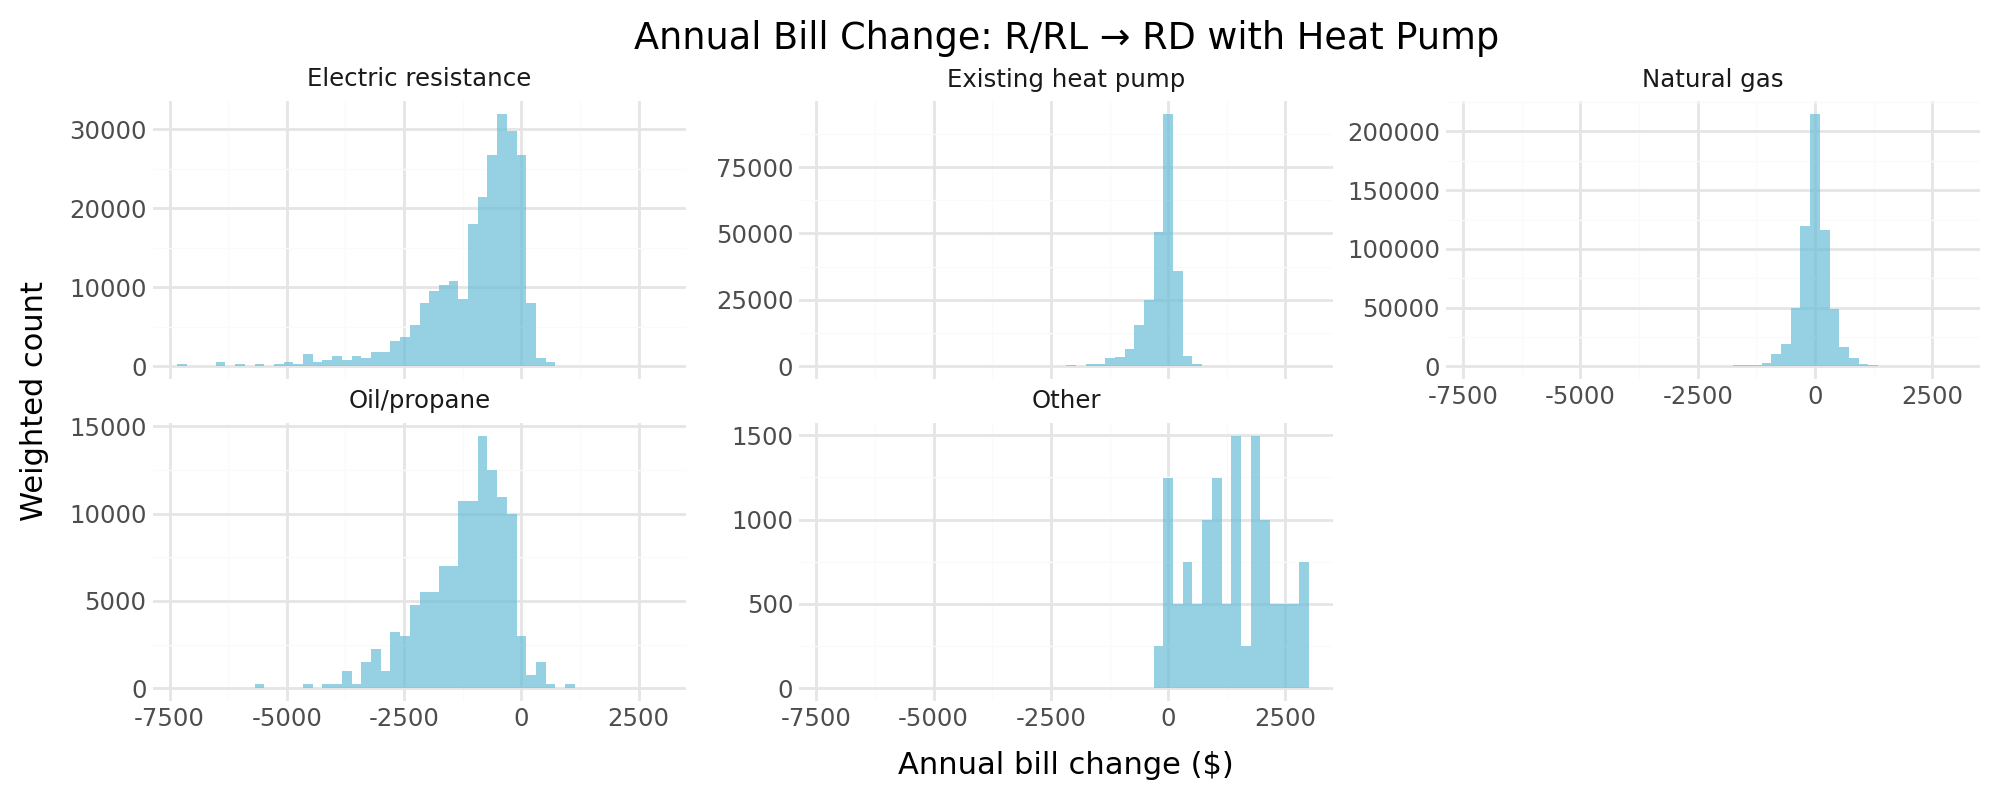

In [38]:
# Compute bill changes
bill_change = (
    bills_default
    .filter(pl.col("month") == "Annual")
    .select([
        "bldg_id",
        "weight",
        "heating_label",
        pl.col("energy_total_bill").alias("bill_default"),
    ])
    .join(
        bills_rd
        .filter(pl.col("month") == "Annual")
        .select([
            "bldg_id",
            pl.col("energy_total_bill").alias("bill_rd"),
        ]),
        on="bldg_id",
        how="inner",
    )
    .with_columns([
        (pl.col("bill_rd") - pl.col("bill_default")).alias("bill_change"),
        ((pl.col("bill_rd") - pl.col("bill_default")) / pl.col("bill_default") * 100).alias("pct_change"),
    ])
)

# Plot
plot = (
    p9.ggplot(bill_change.to_pandas(), p9.aes(x="bill_change", weight="weight"))
    + p9.geom_histogram(bins=50, fill=SB_COLORS["sky"], alpha=0.7)
    + p9.facet_wrap("~ heating_label", scales="free_y")
    + p9.labs(
        x="Annual bill change ($)",
        y="Weighted count",
        title="Annual Bill Change: R/RL → RD with Heat Pump",
    )
    + p9.theme_minimal()
    + p9.theme(figure_size=(10, 4))
)
plot

In [39]:
# Summary statistics
summary = (
    bill_change
    .group_by("heating_label")
    .agg([
        pl.col("bldg_id").count().alias("n_buildings"),
        pl.col("weight").sum().alias("weight_total"),
        (pl.col("bill_change") * pl.col("weight")).sum().alias("weighted_bill_change"),
        (pl.col("pct_change") * pl.col("weight")).sum().alias("weighted_pct_change"),
    ])
    .with_columns([
        (pl.col("weighted_bill_change") / pl.col("weight_total")).alias("mean_bill_change"),
        (pl.col("weighted_pct_change") / pl.col("weight_total")).alias("mean_pct_change"),
    ])
    .sort("heating_label")
)

print(summary)

shape: (5, 7)
┌──────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ heating_labe ┆ n_buildings ┆ weight_tota ┆ weighted_bi ┆ weighted_pc ┆ mean_bill_c ┆ mean_pct_ch │
│ l            ┆ ---         ┆ l           ┆ ll_change   ┆ t_change    ┆ hange       ┆ ange        │
│ ---          ┆ u32         ┆ ---         ┆ ---         ┆ ---         ┆ ---         ┆ ---         │
│ str          ┆             ┆ f64         ┆ f64         ┆ f64         ┆ f64         ┆ f64         │
╞══════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╡
│ Electric     ┆ 945         ┆ 235867.9417 ┆ -2.2801e8   ┆ -5.3014e6   ┆ -966.703887 ┆ -22.476217  │
│ resistance   ┆             ┆ 3           ┆             ┆             ┆             ┆             │
│ Existing     ┆ 974         ┆ 243106.2171 ┆ -3.8417e7   ┆ -836301.447 ┆ -158.024681 ┆ -3.440066   │
│ heat pump    ┆             ┆ 9           ┆             ┆ 316         ┆     

### Savings/Losses Quadrant Bar Chart

This chart shows the distribution of bill changes in four quadrants:

| Bin | Definition |
|-----|------------|
| SAVE > $1K | Annual energy bill decreases by more than $1,000 |
| SAVE $0-1K | Annual energy bill decreases by $0–$1,000 |
| LOSE $0-1K | Annual energy bill increases by $0–$1,000 |
| LOSE > $1K | Annual energy bill increases by more than $1,000 |

A bar leaning heavily green indicates that most households in that group would save
money by switching from R/RL to RD with a heat pump.

In [40]:
from plotnine import (
    aes,
    coord_flip,
    geom_col,
    geom_text,
    ggplot,
    guides,
    labs,
    position_stack,
    scale_fill_manual,
    scale_y_continuous,
    theme,
)
from lib.plotnine import theme_switchbox

# Quadrant definitions
QUADRANT_COLORS: dict[str, str] = {
    "savings > $1k": "#1b5e20",
    "savings $0-1k": "#81c784",
    "losses $0-1k": "#ef9a9a",
    "losses > $1k": "#b71c1c",
}
QUADRANT_ORDER = list(QUADRANT_COLORS.keys())

def quadrant_pcts(df: pl.DataFrame) -> dict[str, float]:
    """Weighted % of households in each bill-change quadrant."""
    total = cast(float, df["weight"].sum())
    return {
        "savings > $1k": cast(float, df.filter(pl.col("bill_change") < -1000)["weight"].sum()) / total * 100,
        "savings $0-1k": cast(
            float,
            df.filter((pl.col("bill_change") >= -1000) & (pl.col("bill_change") < 0))["weight"].sum(),
        ) / total * 100,
        "losses $0-1k": cast(
            float,
            df.filter((pl.col("bill_change") >= 0) & (pl.col("bill_change") < 1000))["weight"].sum(),
        ) / total * 100,
        "losses > $1k": cast(float, df.filter(pl.col("bill_change") >= 1000)["weight"].sum()) / total * 100,
    }

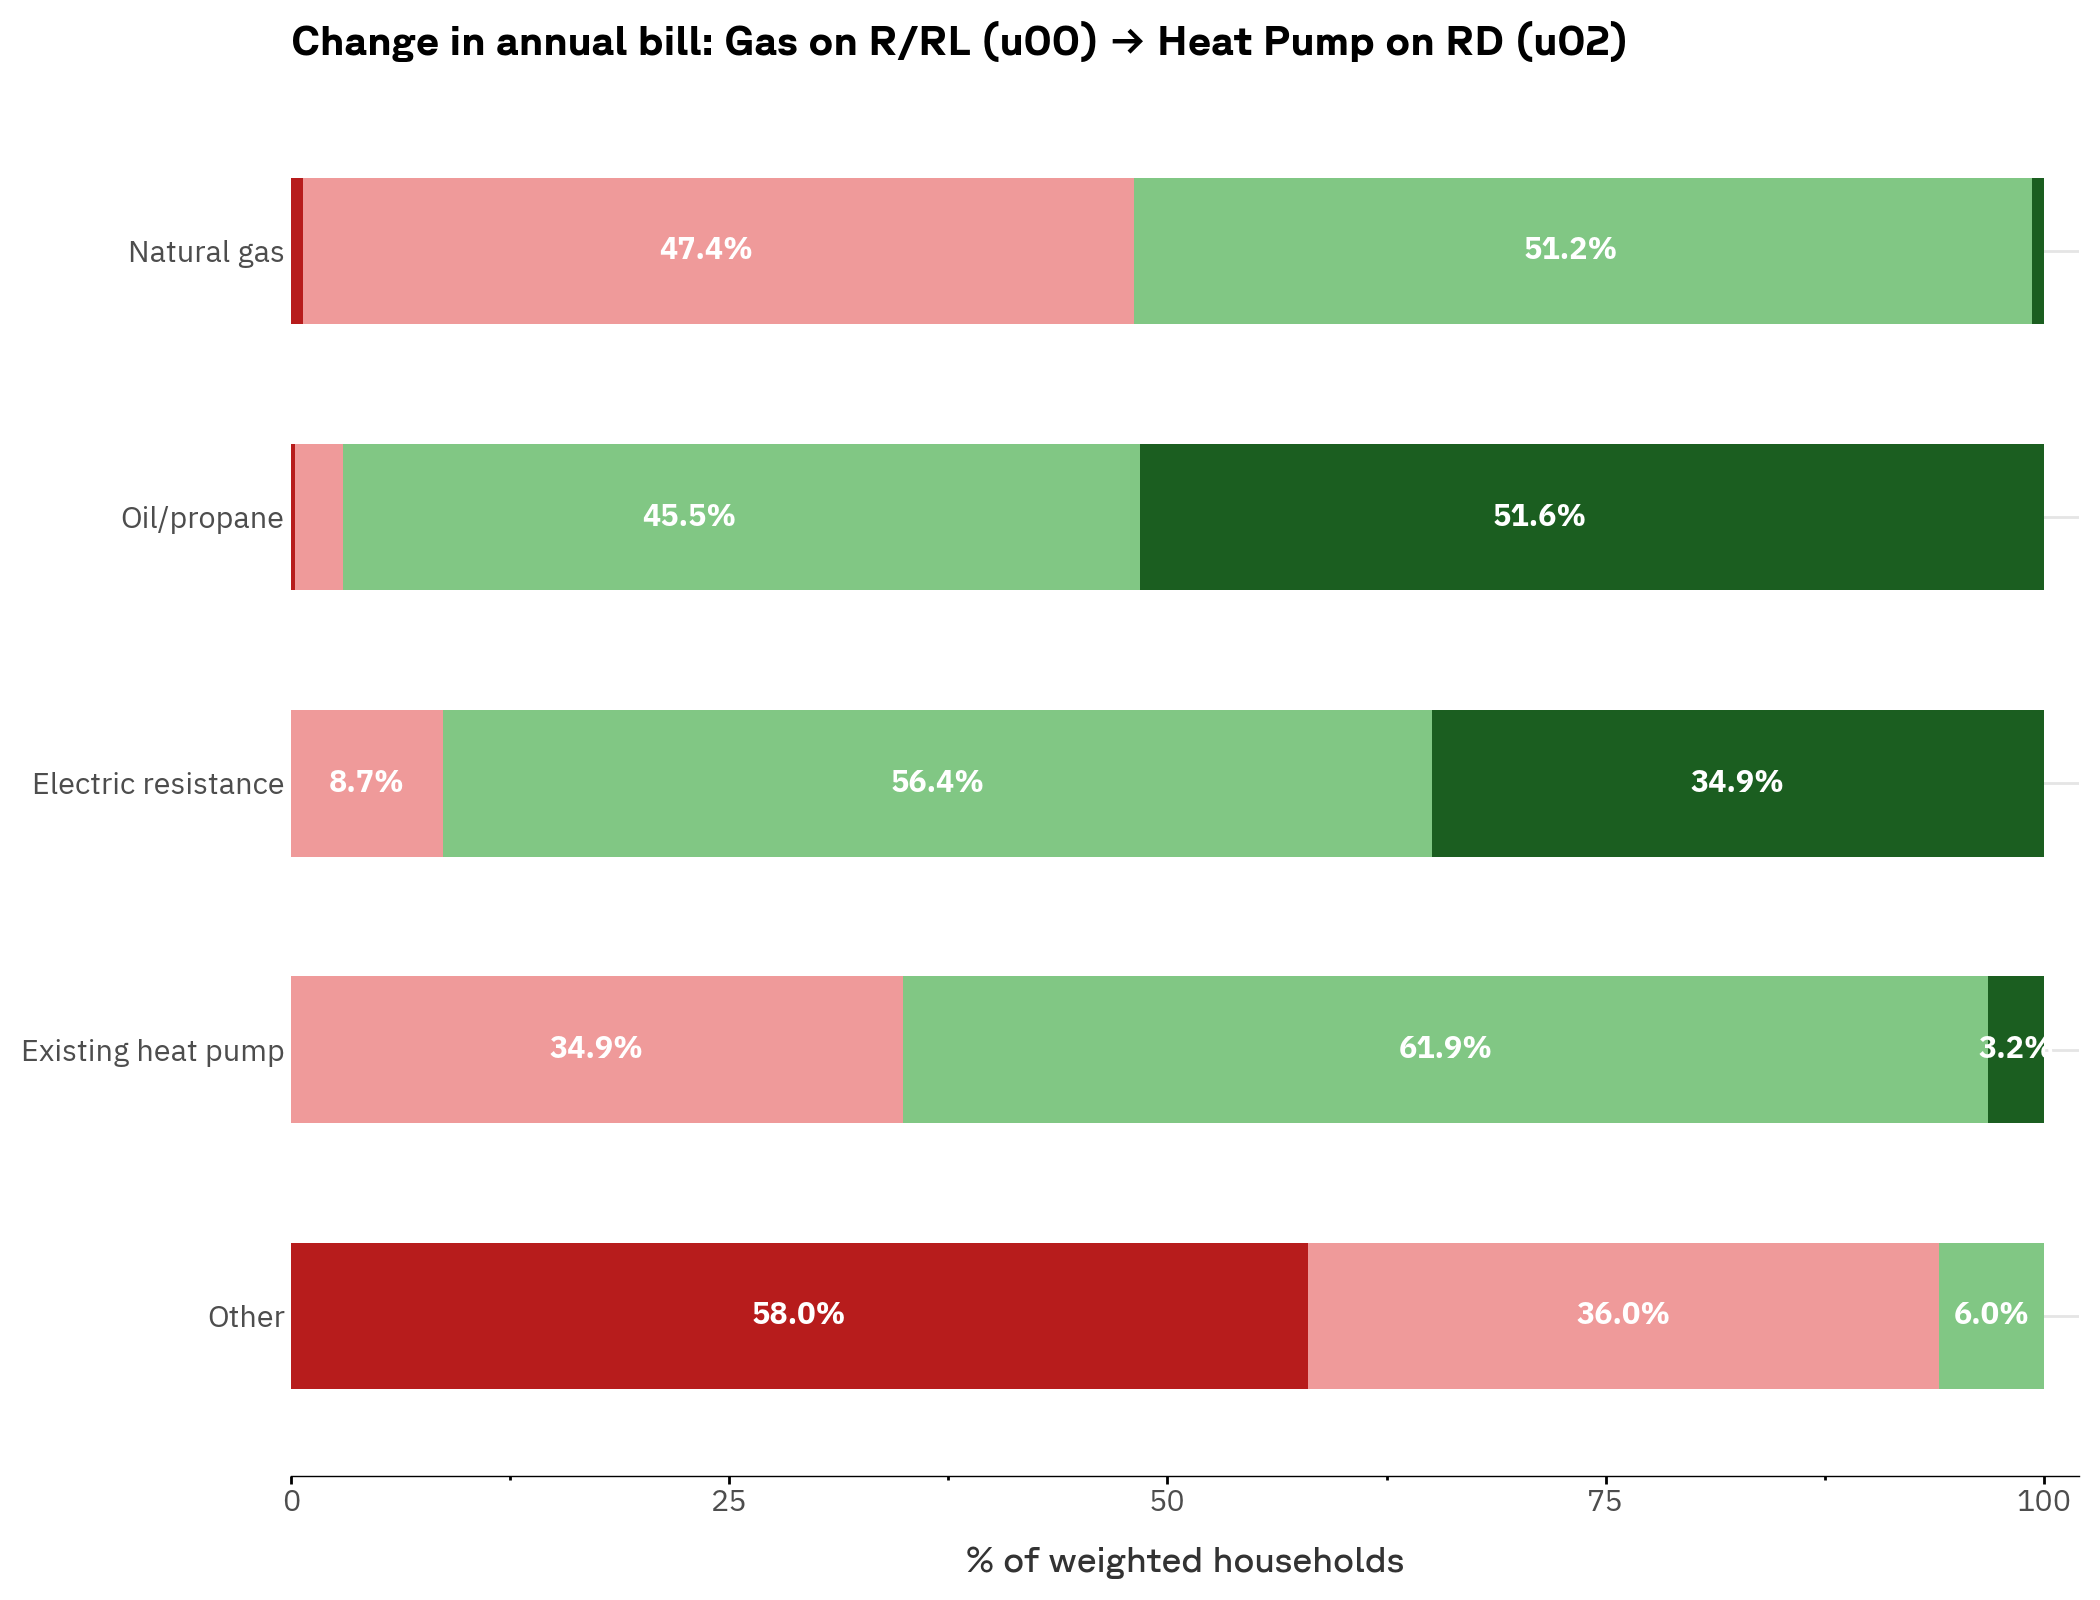

In [41]:
# Calculate quadrant percentages by heating type
avail_heating = sorted(
    bill_change.select("heating_label").unique().to_series().to_list(),
    key=lambda x: HEATING_ORDER.index(x) if x in HEATING_ORDER else 999
)

qb_records: list[dict[str, object]] = []
for group in avail_heating:
    gdf = bill_change.filter(pl.col("heating_label") == group)
    pct = quadrant_pcts(gdf)
    for q in QUADRANT_ORDER:
        qb_records.append({"heating_label": group, "quadrant": q, "pct": pct[q]})

qb_plot = pl.DataFrame(qb_records).with_columns(
    pl.col("heating_label").cast(pl.Enum(list(reversed(avail_heating)))),
    pl.col("quadrant").cast(pl.Enum(QUADRANT_ORDER)),
)

# Create the quadrant bar chart
plot = (
    ggplot(qb_plot, aes(x="heating_label", y="pct", fill="quadrant"))
    + geom_col(position="stack", width=0.55)
    + geom_text(
        mapping=aes(label="pct"),
        data=qb_plot.filter(pl.col("pct") >= 3),
        position=position_stack(vjust=0.5),
        format_string="{:.1f}%",
        color="white",
        size=11,
        fontweight="bold",
    )
    + scale_fill_manual(values=QUADRANT_COLORS, breaks=QUADRANT_ORDER)
    + scale_y_continuous(expand=(0, 0, 0.02, 0))
    + coord_flip()
    + guides(fill=False)
    + labs(
        x="",
        y="% of weighted households",
        title="Change in annual bill: Gas on R/RL (u00) → Heat Pump on RD (u02)",
    )
    + theme_switchbox()
    + theme(figure_size=(10.5, max(3.5, 1.0 + 1.4 * len(avail_heating))))
)

plot

### Savings Breakdown Table

The table below shows the fraction of weighted households in each savings/loss bin,
broken out by baseline heating type.

In [42]:
SAVE_BINS: list[tuple[float, float, str]] = [
    (-float("inf"), -2000, "Save > $2k/yr"),
    (-2000, -1000, "Save $1k-$2k/yr"),
    (-1000, 0, "Save $0-$1k/yr"),
    (0, 1000, "Lose $0-$1k/yr"),
    (1000, float("inf"), "Lose > $1k/yr"),
]

savings_rows: list[dict[str, object]] = []
for group in avail_heating:
    gdf = bill_change.filter(pl.col("heating_label") == group)
    total_w = cast(float, gdf["weight"].sum())
    row: dict[str, object] = {
        "Baseline heating": group,
        "Buildings": gdf.height,
        "Weighted hholds": round(total_w),
    }
    for lo, hi, label in SAVE_BINS:
        if lo == -float("inf"):
            filt = gdf.filter(pl.col("bill_change") < hi)
        elif hi == float("inf"):
            filt = gdf.filter(pl.col("bill_change") >= lo)
        else:
            filt = gdf.filter((pl.col("bill_change") >= lo) & (pl.col("bill_change") < hi))
        row[label] = f"{cast(float, filt['weight'].sum()) / total_w * 100:.1f}%"
    row["Mean change ($/yr)"] = f"${weighted_mean(gdf, 'bill_change'):,.0f}"
    row["Median change ($/yr)"] = f"${weighted_quantile(gdf, 'bill_change', 0.5):,.0f}"
    savings_rows.append(row)

savings_df = pl.DataFrame(savings_rows)
print("Bill change by baseline heating type (% of weighted households in each bin):")
savings_df

Bill change by baseline heating type (% of weighted households in each bin):


Baseline heating,Buildings,Weighted hholds,Save > $2k/yr,Save $1k-$2k/yr,Save $0-$1k/yr,Lose $0-$1k/yr,Lose > $1k/yr,Mean change ($/yr),Median change ($/yr)
str,i64,i64,str,str,str,str,str,str,str
"""Natural gas""",2455,612757,"""0.0%""","""0.7%""","""51.2%""","""47.4%""","""0.7%""","""$-13""","""$-9"""
"""Oil/propane""",473,118059,"""19.5%""","""32.1%""","""45.5%""","""2.7%""","""0.2%""","""$-1,217""","""$-1,036"""
"""Electric resistance""",945,235868,"""13.1%""","""21.8%""","""56.4%""","""8.7%""","""0.0%""","""$-967""","""$-656"""
"""Existing heat pump""",974,243106,"""0.2%""","""3.0%""","""61.9%""","""34.9%""","""0.0%""","""$-158""","""$-67"""
"""Other""",50,12480,"""0.0%""","""0.0%""","""6.0%""","""36.0%""","""58.0%""","""$1,339""","""$1,443"""


## Cross-Subsidization (BAT) Analysis

In [43]:
# Compare BAT metrics
bat_comparison = (
    bat_default
    .select([
        "bldg_id",
        "heating_label",
        "weight",
        pl.col("BAT_vol_total").alias("bat_default"),
    ])
    .join(
        bat_rd.select([
            "bldg_id",
            pl.col("BAT_vol_total").alias("bat_rd"),
        ]),
        on="bldg_id",
        how="inner",
    )
    .with_columns([
        (pl.col("bat_rd") - pl.col("bat_default")).alias("bat_change"),
    ])
)

# Summary by heating type
bat_summary = (
    bat_comparison
    .group_by("heating_label")
    .agg([
        pl.col("bldg_id").count().alias("n_buildings"),
        pl.col("weight").sum().alias("weight_total"),
        (pl.col("bat_default") * pl.col("weight")).sum().alias("weighted_bat_default"),
        (pl.col("bat_rd") * pl.col("weight")).sum().alias("weighted_bat_rd"),
        (pl.col("bat_change") * pl.col("weight")).sum().alias("weighted_bat_change"),
    ])
    .with_columns([
        (pl.col("weighted_bat_default") / pl.col("weight_total")).alias("mean_bat_default"),
        (pl.col("weighted_bat_rd") / pl.col("weight_total")).alias("mean_bat_rd"),
        (pl.col("weighted_bat_change") / pl.col("weight_total")).alias("mean_bat_change"),
    ])
    .sort("heating_label")
)

print(bat_summary)

shape: (5, 9)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ heating_l ┆ n_buildin ┆ weight_to ┆ weighted_ ┆ … ┆ weighted_ ┆ mean_bat_ ┆ mean_bat_ ┆ mean_bat │
│ abel      ┆ gs        ┆ tal       ┆ bat_defau ┆   ┆ bat_chang ┆ default   ┆ rd        ┆ _change  │
│ ---       ┆ ---       ┆ ---       ┆ lt        ┆   ┆ e         ┆ ---       ┆ ---       ┆ ---      │
│ str       ┆ u32       ┆ f64       ┆ ---       ┆   ┆ ---       ┆ f64       ┆ f64       ┆ f64      │
│           ┆           ┆           ┆ f64       ┆   ┆ f64       ┆           ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ Electric  ┆ 945       ┆ 235867.94 ┆ 4.0155e7  ┆ … ┆ -1.7363e1 ┆ 170.24238 ┆ -735981.5 ┆ -736151. │
│ resistanc ┆           ┆ 173       ┆           ┆   ┆ 1         ┆ 7         ┆ 77748     ┆ 820135   │
│ e         ┆           ┆           ┆           ┆   ┆           ┆           ┆